In [41]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,r2_score, mean_absolute_error, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from ydata_profiling import ProfileReport
from sklearn.cluster import KMeans

cust = pd.DataFrame(pd.read_csv(r'C:\Users\cust.csv'))
prod = pd.DataFrame(pd.read_csv(r'C:\Users\products.csv'))
ords = pd.DataFrame(pd.read_csv(r'C:\Users\orders.csv'))

ords['order_date'] = pd.to_datetime(ords['order_date'],errors='coerce')

print('Customer DataFrame')
print(cust.info())

print('\n\nProduction DataFrame')
print(prod.info())

print('\n\nOrder DataFrame')
print(ords.info())



Customer DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  5 non-null      object
 1   name         5 non-null      object
 2   city         5 non-null      object
 3   segment      5 non-null      object
dtypes: object(4)
memory usage: 292.0+ bytes
None


Production DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    4 non-null      object
 1   product_name  4 non-null      object
 2   category      4 non-null      object
 3   unit_price    4 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 260.0+ bytes
None


Order DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column       Non-Null Count

In [42]:
#Clean DataFrame objects
ords['order_date'] = pd.to_datetime(ords['order_date'],errors = 'coerce')

#Join all DataFrames together into 1 dataset
data = pd.merge(
    cust,
    ords,
    left_on='customer_id',
    right_on='customer_id',
    how='left'
)

data = pd.merge(
    data,
    prod,
    left_on='product_id',
    right_on='product_id',
    how='left'
)

#Clean the Data
data = data.dropna(how='all')
data = data.drop_duplicates()

#Display full dataset
print(data.info())
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   customer_id   8 non-null      object        
 1   name          8 non-null      object        
 2   city          8 non-null      object        
 3   segment       8 non-null      object        
 4   order_id      8 non-null      object        
 5   order_date    8 non-null      datetime64[ns]
 6   product_id    8 non-null      object        
 7   quantity      8 non-null      int64         
 8   product_name  8 non-null      object        
 9   category      8 non-null      object        
 10  unit_price    8 non-null      int64         
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 836.0+ bytes
None
  customer_id          name     city    segment order_id order_date  \
0        C001     Ana Lopez    Miami   Consumer    O1001 2026-09-01   
1        C001     Ana Lopez 

In [43]:
# Create the new attribute called profit
data['profit'] = data['unit_price'] * data['quantity']

# Create a separate dataframe with less attributes for analysis
df = data[['name','city','segment','order_date','quantity','unit_price','product_name','category','profit']]

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   name          8 non-null      object        
 1   city          8 non-null      object        
 2   segment       8 non-null      object        
 3   order_date    8 non-null      datetime64[ns]
 4   quantity      8 non-null      int64         
 5   unit_price    8 non-null      int64         
 6   product_name  8 non-null      object        
 7   category      8 non-null      object        
 8   profit        8 non-null      int64         
dtypes: datetime64[ns](1), int64(3), object(5)
memory usage: 708.0+ bytes
None


## Total Profit Calculation

In [44]:
print(df['profit'].sum())

486


#### We have the unit price and unit cost attributes so we can calculate the profit. We do not have the cost of goods and services and discounts.

## Total Profit by Product

product_name
Keyboard          225
Desk Lamp         150
Wireless Mouse     75
Notebook           36
Name: profit, dtype: int64


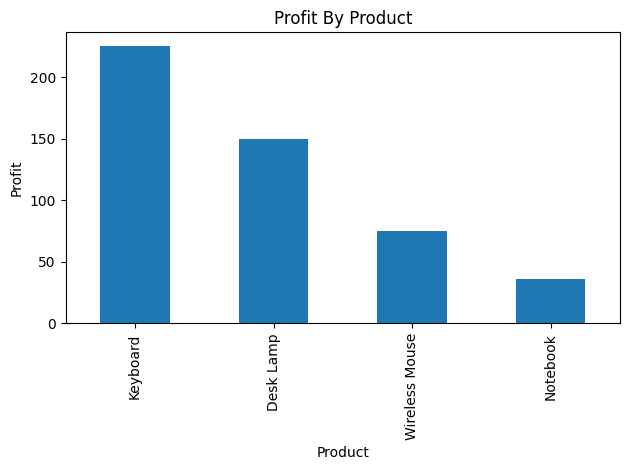


product_name
Desk Lamp         5
Keyboard          5
Notebook          3
Wireless Mouse    3
Name: quantity, dtype: int64


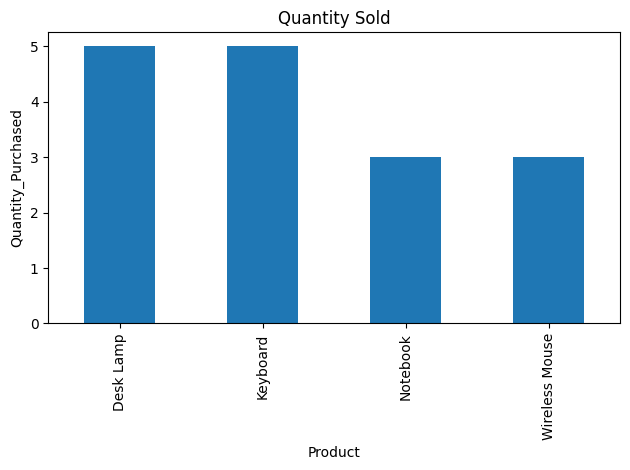

In [45]:
product_profit = df.groupby('product_name')['profit'].sum().sort_values(ascending=False)
product_quantity = df.groupby('product_name')['quantity'].sum().sort_values(ascending=False)

print(product_profit)

product_profit.plot(kind='bar')
plt.xlabel('Product')
plt.ylabel('Profit')
plt.title('Profit By Product')
plt.tight_layout()
plt.show()

print(f'\n{product_quantity}')
product_quantity.plot(kind='bar')
plt.xlabel('Product')
plt.ylabel('Quantity_Purchased')
plt.title('Quantity Sold')
plt.tight_layout()
plt.show()

#### We can see that the keyboard contributes to the highest profit at $225 with 5 sold and the Notebook contributed to the lowest profit at $36 with only 3 sold.

## Profit per Segment

segment
Consumer       342
Corporate      120
Home Office     24
Name: profit, dtype: int64


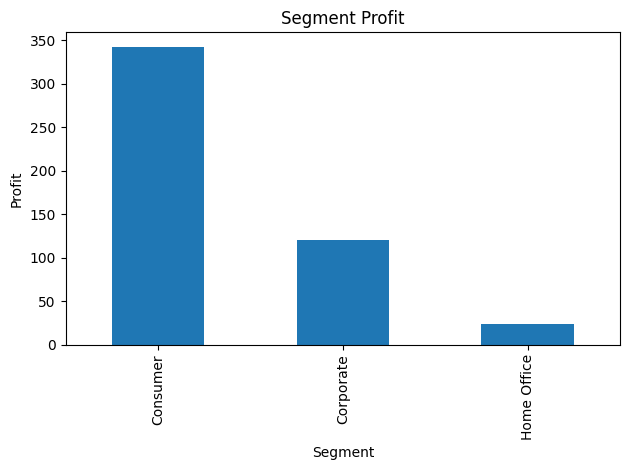


segment
Consumer       11
Corporate       3
Home Office     2
Name: quantity, dtype: int64


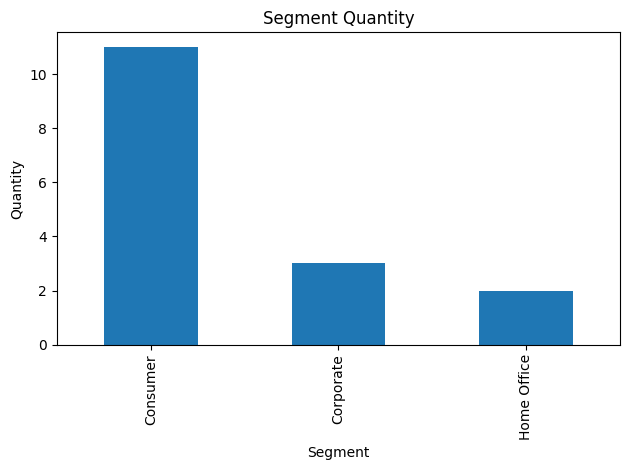

In [46]:
segment_profit = df.groupby('segment')['profit'].sum().sort_values(ascending = False)
segment_quantity = df.groupby('segment')['quantity'].sum().sort_values(ascending=False)

print(segment_profit)

segment_profit.plot(kind='bar')
plt.xlabel('Segment')
plt.ylabel('Profit')
plt.title('Segment Profit')
plt.tight_layout()
plt.show()

print(f'\n{segment_quantity}')

segment_quantity.plot(kind='bar')
plt.xlabel('Segment')
plt.ylabel('Quantity')
plt.title('Segment Quantity')
plt.tight_layout()
plt.show()

#### The segment with the highest profit is Consumer at $342 with 11 units sold and Home Office with the lowest at $24 with only 2.  

## Profit by customer

name
Ana Lopez       185
James Carter    120
Maya Patel      120
Sofia Chen       37
Liam Brown       24
Name: profit, dtype: int64


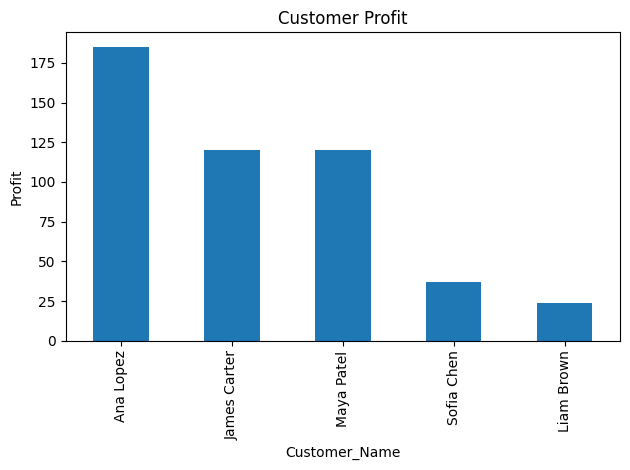


name
Ana Lopez       5
Maya Patel      4
James Carter    3
Liam Brown      2
Sofia Chen      2
Name: quantity, dtype: int64


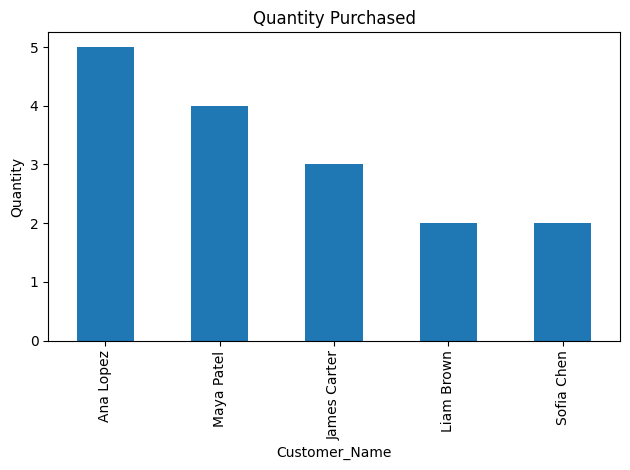

In [47]:
customer_profit = df.groupby('name')['profit'].sum().sort_values(ascending=False)
customer_quantity = df.groupby('name')['quantity'].sum().sort_values(ascending=False)

print(customer_profit)

customer_profit.plot(kind='bar')
plt.xlabel('Customer_Name')
plt.ylabel('Profit')
plt.title('Customer Profit')
plt.tight_layout()
plt.show()

print(f'\n{customer_quantity}')
customer_quantity.plot(kind = 'bar')
plt.xlabel('Customer_Name')
plt.ylabel('Quantity')
plt.title('Quantity Purchased')
plt.tight_layout()
plt.show()

#### Ana Lopez is the customer that spent the most at $185 with 5 items purchased and Liam Brown spent the least at $24 with 2 items purchased.

## Coorelation Check

quantity      0.862356
unit_price    0.787970
profit        1.000000
Name: profit, dtype: float64


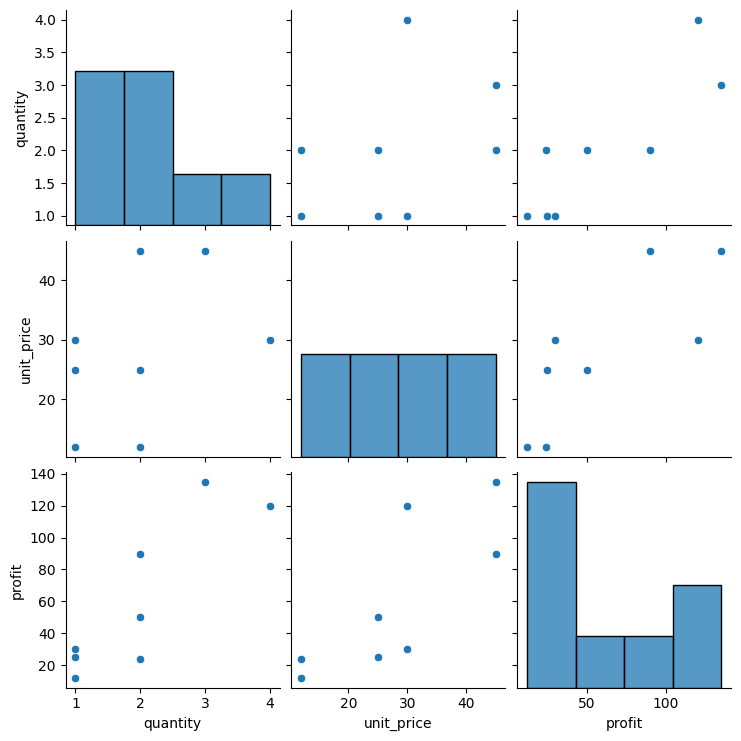

In [48]:
correlation = df.corr(numeric_only=True)['profit']

print(correlation)

sns.pairplot(df)
plt.show()

## Linear Regression

In [49]:
x = df[['quantity','unit_price']]
y = df['profit']

x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size = 0.25,
    random_state=42
)

model = LinearRegression()
model.fit(x_train,y_train)
r2 = model.score(x_test,y_test)
print(f'The r2 score is {r2}')

The r2 score is 0.9349684808557466


## Cluster Customers based on their total spending and quantity purchased

In [50]:
customer_cluster = df.groupby('name')[['quantity','profit']].sum()
customer_cluster = pd.DataFrame(customer_cluster)

x = customer_cluster[['profit','quantity']]

model = KMeans(
    n_clusters=3,
    random_state=42
)
model.fit(x)
clst = model.labels_

customer_cluster['cluster'] = clst

print(customer_cluster)


              quantity  profit  cluster
name                                   
Ana Lopez            5     185        2
James Carter         3     120        0
Liam Brown           2      24        1
Maya Patel           4     120        0
Sofia Chen           2      37        1
